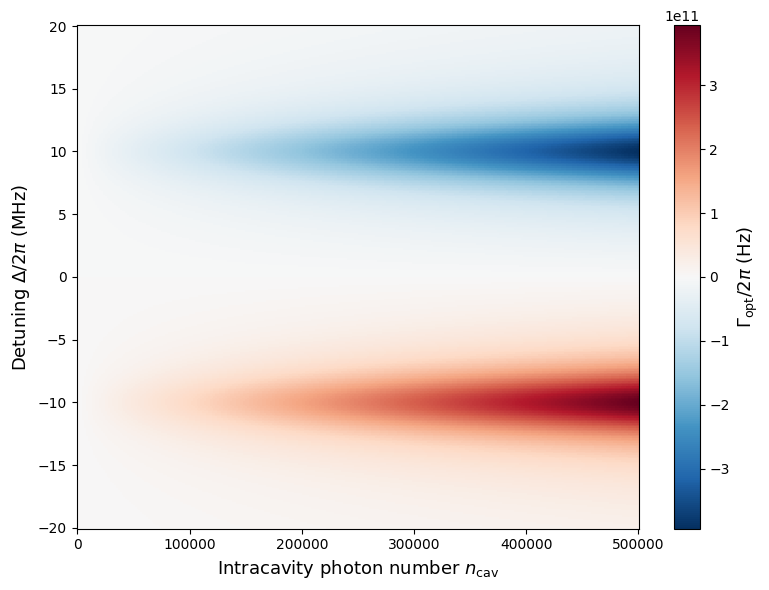

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Parameters
# ==========================

g0 = 2*np.pi*1e6        # Single-photon coupling (Hz)
Omega_m = 2*np.pi*10e6  # Mechanical frequency (Hz)
kappa = 2*np.pi*5e6     # Optical linewidth (Hz)

# ==========================
# Grid
# ==========================

n_cav = np.linspace(0, 5e5, 300)
Delta = np.linspace(-2*Omega_m, 2*Omega_m, 300)

N, D = np.meshgrid(n_cav, Delta)

# Enhanced coupling
g = g0*np.sqrt(N)

# ==========================
# Optomechanical damping
# ==========================

Gamma_opt = g**2 * (
    kappa / ((D + Omega_m)**2 + (kappa/2)**2)
    -
    kappa / ((D - Omega_m)**2 + (kappa/2)**2)
)

# ==========================
# Plot
# ==========================

plt.figure(figsize=(8,6))

im = plt.pcolormesh(
    N,
    D/(2*np.pi*1e6),     # MHz
    Gamma_opt/(2*np.pi), # Hz
    shading='auto',
    cmap='RdBu_r'
)

plt.xlabel(r'Intracavity photon number $n_{\rm cav}$', fontsize=13)
plt.ylabel(r'Detuning $\Delta/2\pi$ (MHz)', fontsize=13)

cbar = plt.colorbar(im)
cbar.set_label(r'$\Gamma_{\rm opt}/2\pi$ (Hz)', fontsize=13)

plt.tight_layout()
plt.show()